In [1]:
from pyprojroot import here
print("Project root:", here())

Project root: C:\Users\hanis\Flight\flight-delay-prediction


# Relationship EDA

### The phase of data analysis where you look at how two or more variables interact with each other.
Let's start by seeing all the columns present

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_parquet(here("data/processed/clean.parquet"))
print(df.columns)
df.head()

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
       'Reporting_Airline', 'DOT_ID_Reporting_Airline',
       'IATA_CODE_Reporting_Airline', 'Tail_Number',
       'Flight_Number_Reporting_Airline', 'OriginAirportID',
       'OriginAirportSeqID', 'OriginCityMarketID', 'Origin', 'OriginCityName',
       'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac',
       'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'Dest',
       'DestCityName', 'DestState', 'DestStateFips', 'DestStateName',
       'DestWac', 'CRSDepTime', 'DepDelay', 'DepDelayMinutes', 'DepDel15',
       'DepartureDelayGroups', 'DepTimeBlk', 'CRSArrTime',
       'ArrivalDelayGroups', 'ArrTimeBlk', 'Flights', 'Distance',
       'DistanceGroup'],
      dtype='object')


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,DepDelayMinutes,DepDel15,DepartureDelayGroups,DepTimeBlk,CRSArrTime,ArrivalDelayGroups,ArrTimeBlk,Flights,Distance,DistanceGroup
0,2024,4,10,29,2,2024-10-29,UA,19977,UA,N37504,...,0.0,0.0,-1.0,1300-1359,1532,-2.0,1500-1559,1.0,2133.0,9
1,2024,4,10,29,2,2024-10-29,UA,19977,UA,N69824,...,0.0,0.0,-1.0,1900-1959,2056,-2.0,2000-2059,1.0,455.0,2
2,2024,4,10,29,2,2024-10-29,UA,19977,UA,N37297,...,0.0,0.0,-1.0,0900-0959,1218,-2.0,1200-1259,1.0,1041.0,5
3,2024,4,10,29,2,2024-10-29,UA,19977,UA,N47569,...,0.0,0.0,-1.0,1300-1359,1505,-2.0,1500-1559,1.0,888.0,4
4,2024,4,10,29,2,2024-10-29,UA,19977,UA,N69826,...,0.0,0.0,-1.0,1200-1259,1538,-1.0,1500-1559,1.0,1846.0,8


# 1. Airline vs DepDel15


   Reporting_Airline  total_flights  delay_rate
13                WN         573997   18.992085
4                 DL         425671   14.790766
1                 AA         401987   20.920328
11                OO         327565   16.343321
12                UA         322702   15.801885
14                YX         130711   11.136018
8                 MQ         116406   14.223494
2                 AS         103731   18.005225
9                 NK         102448   21.310323
10                OH         100761   18.602435
3                 B6          96439   23.207416
5                 F9          87129   24.223852
0                 9E          81686   12.510100
6                 G4          43925   20.500854
7                 HA          32686   10.521324


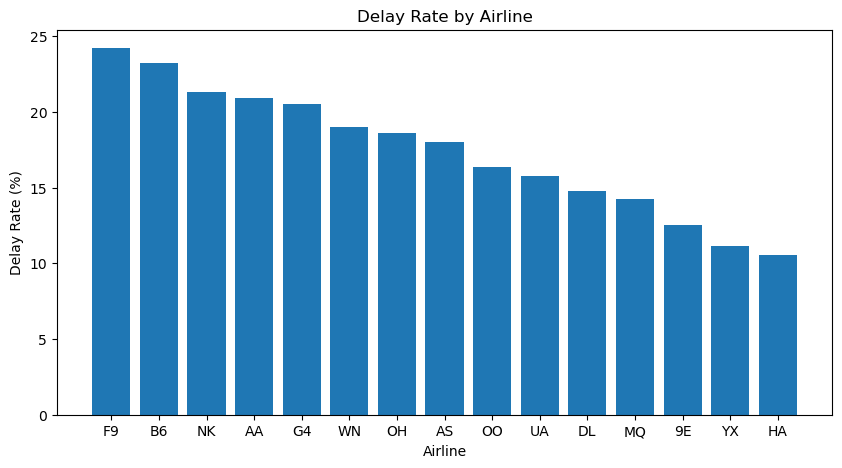

In [3]:
airline_delay = (
    df.groupby("Reporting_Airline")
    .agg(
        total_flights=("DepDel15", "count"),
        delay_rate=("DepDel15", "mean")
    )
    .reset_index()
)

airline_delay["delay_rate"] *= 100

airline_delay.sort_values(
    "delay_rate",
    ascending=False,
    inplace=True
)

airline_delay.head()

plt.figure(figsize=(10,5))

plt.bar(
    airline_delay["Reporting_Airline"],
    airline_delay["delay_rate"]
)

plt.xlabel("Airline")
plt.ylabel("Delay Rate (%)")
plt.title("Delay Rate by Airline")

airline_delay.sort_values(
    "total_flights",
    ascending=False,
    inplace=True
)

print(airline_delay)

# 2. Day of week vs DepDel15


   DayOfWeek  total_flights  delay_rate
0          1         449699   17.445669
1          2         395878   13.076503
2          3         384271   13.635169
3          4         437337   19.307079
4          5         447521   20.613558
5          6         384074   17.707785
6          7         449064   19.997372


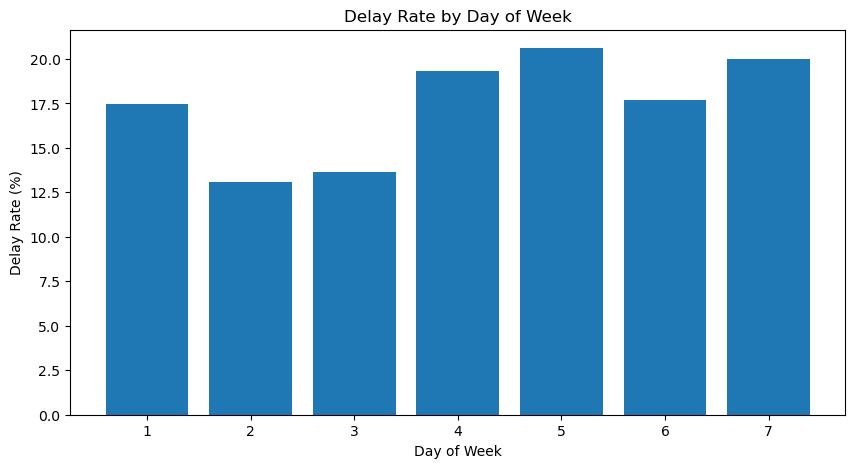

In [4]:
dayOfWeek_delay = (
    df.groupby("DayOfWeek")
    .agg(
        total_flights=("DepDel15", "count"),
        delay_rate=("DepDel15", "mean")
    )
    .reset_index()
)

dayOfWeek_delay["delay_rate"] *= 100

dayOfWeek_delay.head()

plt.figure(figsize=(10,5))

plt.bar(
    dayOfWeek_delay["DayOfWeek"],
    dayOfWeek_delay["delay_rate"]
)

plt.xlabel("Day of Week")
plt.ylabel("Delay Rate (%)")
plt.title("Delay Rate by Day of Week")

print(dayOfWeek_delay)
